# Geomagnetic Indices — 9–10 May 2024

Generates a 3-panel figure (**Dst, Kp, Ap**) for the 9–10 May 2024 geomagnetic storm event.

The plotting logic is written **once**, as a reusable function. Each event
(a contiguous run of days) is just a block of data plus a single function call —
so adding a new event later means adding a new data block + call, not touching
the plotting code itself. Each event produces its own output PNG.


In [1]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Import publication styles and paths from your config
from src.configs.config import (
    GEOMAGNETIC_INDICES_DIR,
    PLOT_LABEL_FONTSIZE,
    PLOT_LABEL_FONTWEIGHT,
    PLOT_TICK_FONTSIZE,
    PLOT_TICK_FONTWEIGHT,
    PLOT_LEGEND_FONTSIZE,
    PLOT_LEGEND_FONTWEIGHT,
    PLOT_GRID_ALPHA,
    PLOT_DPI,
)

# Ensure the targeted metric indices directory exists before saving files
GEOMAGNETIC_INDICES_DIR.mkdir(parents=True, exist_ok=True)


### Helpers
Time-axis builders and the shared styling used across the loss / prediction /
delay plots elsewhere in this project (bold 13pt axis labels, bold 11pt
ticks, bold 11pt legend).


In [2]:
def hourly_times(start_date, n):
    """n hourly timestamps starting at start_date (used for Dst)."""
    return [start_date + timedelta(hours=i) for i in range(n)]


def three_hourly_times(start_date, n):
    """n 3-hourly timestamps starting at start_date (used for Kp, Ap)."""
    return [start_date + timedelta(hours=3 * i) for i in range(n)]


def _style_axis(ax, ylabel):
    ax.set_ylabel(ylabel, fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT)
    ax.grid(alpha=PLOT_GRID_ALPHA)
    ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight(PLOT_TICK_FONTWEIGHT)


def _panel_label(ax, label):
    ax.text(-0.06, 1.05, label, transform=ax.transAxes,
            fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT,
            va="bottom", ha="right")


### Reusable event-plotting function
```text
Call once per event (a contiguous block of days). Handles any number of
days automatically — the number of days is inferred from len(dst)/24.

Inputs (all UT):
  event_label : str       e.g. "9-10 May 2024"  (used on the x-axis label)
  start_date  : datetime  first day, 00:00 UT
  dst         : list[float]  hourly values,        len == 24 * n_days
  kp          : list[float]  3-hourly values,      len ==  8 * n_days
  ap          : list[float]  3-hourly values,      len ==  8 * n_days
  filename    : str       output PNG name, saved under GEOMAGNETIC_INDICES_DIR

Returns: the saved file path.
```

In [3]:
def plot_geomagnetic_event(event_label, start_date, dst, kp, ap, filename):
    n_days = len(dst) // 24
    assert len(dst) == 24 * n_days, "dst must have 24 hourly values per day"
    assert len(kp)  ==  8 * n_days, "kp must have 8 three-hourly values per day"
    assert len(ap)  ==  8 * n_days, "ap must have 8 three-hourly values per day"

    dst_times  = hourly_times(start_date, 24 * n_days)
    kpap_times = three_hourly_times(start_date, 8 * n_days)

    fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(dst_times, dst, color='#1f77b4', marker='o', markersize=3)
    axes[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
    _style_axis(axes[0], "Dst (nT)")

    axes[1].step(kpap_times, kp, where='post', color='#ff7f0e', marker='o', markersize=4)
    axes[1].axhline(9, color='red', linewidth=0.7, linestyle=':')
    _style_axis(axes[1], "Kp index")

    axes[2].step(kpap_times, ap, where='post', color='#2ca02c', marker='o', markersize=4)
    _style_axis(axes[2], "Ap index")

    # Day-boundary guide lines for multi-day events
    for d in range(1, n_days):
        boundary = start_date + timedelta(hours=24 * d)
        for ax in axes:
            ax.axvline(boundary, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

    # 12-hour ticks: 00:00, 12:00, 00:00, 12:00 ... then 23:59 at the end
    tick_hours = list(range(0, 24 * n_days, 12))
    ticks  = [start_date + timedelta(hours=h) for h in tick_hours]
    labels = [f"{h % 24:02d}:00" for h in tick_hours]
    ticks.append(start_date + timedelta(hours=24 * n_days - 1, minutes=59))
    labels.append("23:59")

    axes[-1].set_xticks(ticks)
    axes[-1].set_xticklabels(labels, rotation=45,
                              fontsize=PLOT_TICK_FONTSIZE, fontweight=PLOT_TICK_FONTWEIGHT)
    axes[-1].set_xlabel(f"Time (UT) — {event_label}",
                         fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT)
    axes[-1].set_xlim(start_date, start_date + timedelta(hours=24 * n_days))

    for ax, label in zip(axes, ['a', 'b', 'c']):
        _panel_label(ax, label)

    fig.tight_layout()

    save_path = GEOMAGNETIC_INDICES_DIR / filename
    fig.savefig(save_path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")
    return save_path


---
## Event 1 — 9–10 May 2024

Dst, Kp, and Ap values for the 9–10 May 2024 geomagnetic storm (real observed data).


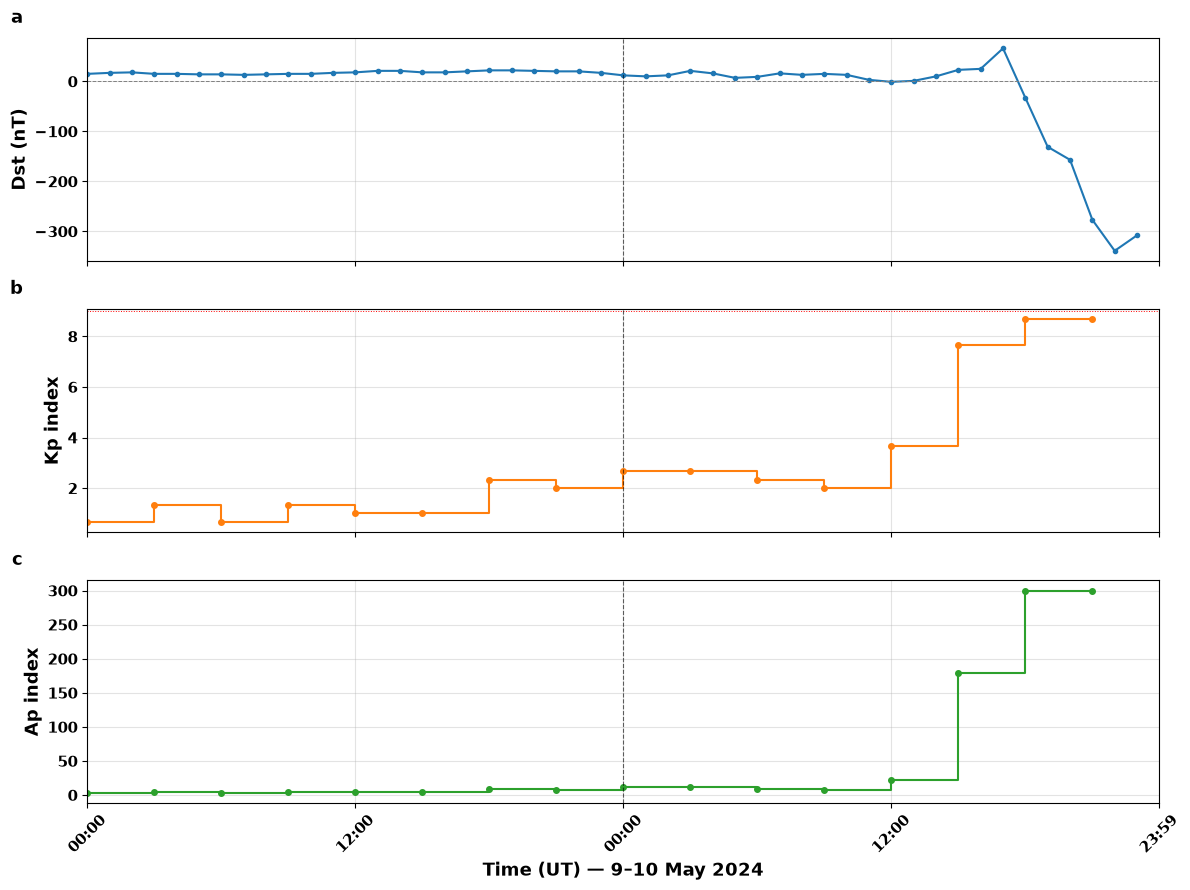

Saved: C:\Users\avran\OneDrive\Desktop\ionospheric-tec-forecasting\generated_plots\geomagnetic_indices_plots\geomag_9_10may2024.png


WindowsPath('C:/Users/avran/OneDrive/Desktop/ionospheric-tec-forecasting/generated_plots/geomagnetic_indices_plots/geomag_9_10may2024.png')

In [4]:
event1_label = "9–10 May 2024"
event1_start = datetime(2024, 5, 9)

dst_event1 = (
    [15, 17, 18, 15, 15, 14, 14, 13, 14, 15, 15, 17, 18, 21, 21, 18, 18, 20, 22, 22, 21, 20, 20, 17]   # 9 May
    + [12, 10, 12, 21, 16, 7, 9, 16, 13, 15, 13, 3, -1, 1, 10, 23, 25, 66, -33, -131, -157, -277, -339, -308]  # 10 May
)

kp_event1 = (
    [0.667, 1.333, 0.667, 1.333, 1.000, 1.000, 2.333, 2.000]   # 9 May
    + [2.667, 2.667, 2.333, 2.000, 3.667, 7.667, 8.667, 8.667]  # 10 May
)

ap_event1 = (
    [3, 5, 3, 5, 4, 4, 9, 7]        # 9 May
    + [12, 12, 9, 7, 22, 179, 300, 300]  # 10 May
)

plot_geomagnetic_event(
    event_label=event1_label,
    start_date=event1_start,
    dst=dst_event1,
    kp=kp_event1,
    ap=ap_event1,
    filename="geomag_9_10may2024.png",
)
